In [1]:
from misc import *
import constant

import zfit

# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]
df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-01-27 02:03:28.991575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737943409.013217 2379459 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737943409.020248 2379459 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2025-01-27 02:03:37.040647: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-01-27 02:03:37.040793: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.86.10 -- cannot find working devices in this configuration


FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda, lambda]] data=[<zfit.Data: Data obs=('Bplus_M',) shape=(12973, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 1.3e-05 │         93137.33 |  7718.487 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
lambda         -0.00205508       False
Histogram not saved to file
Histogram not saved to file


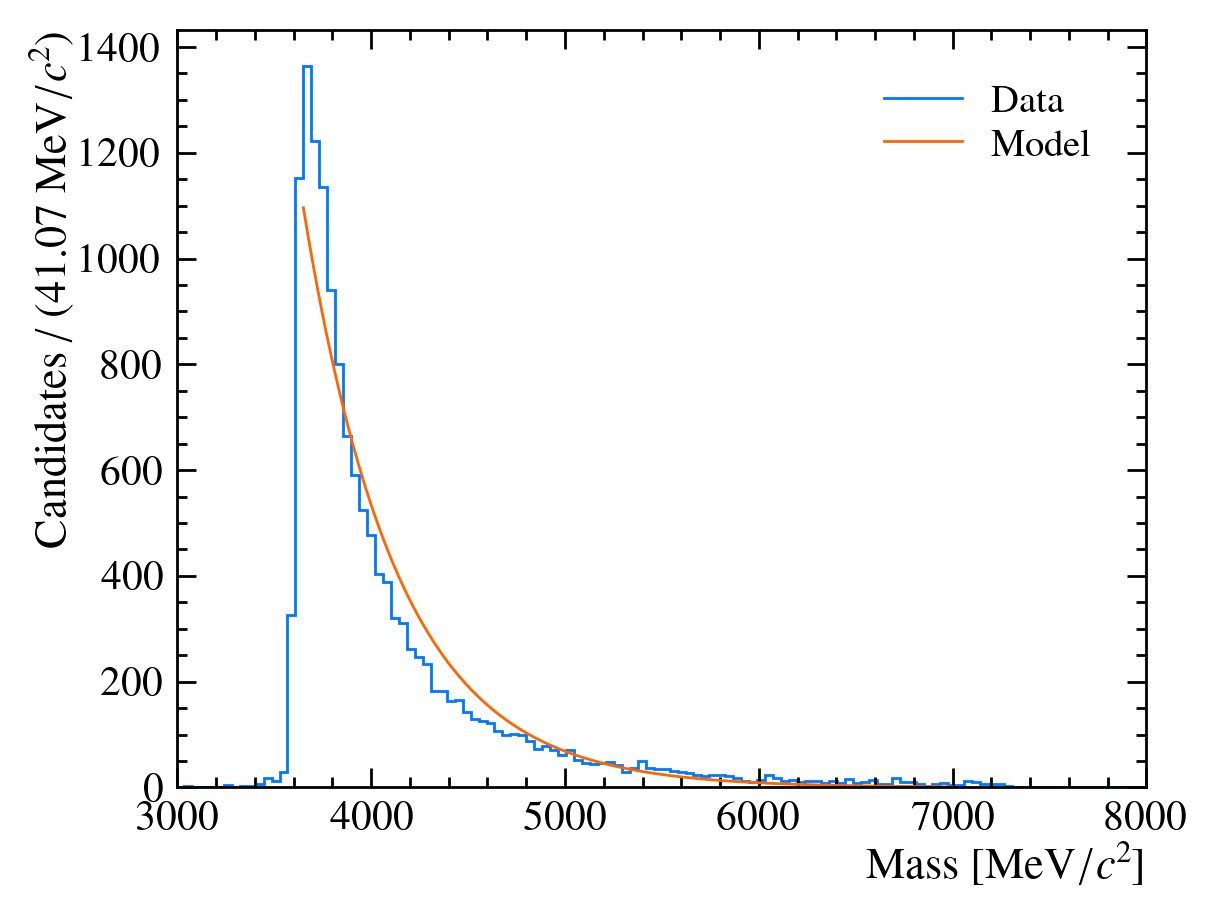

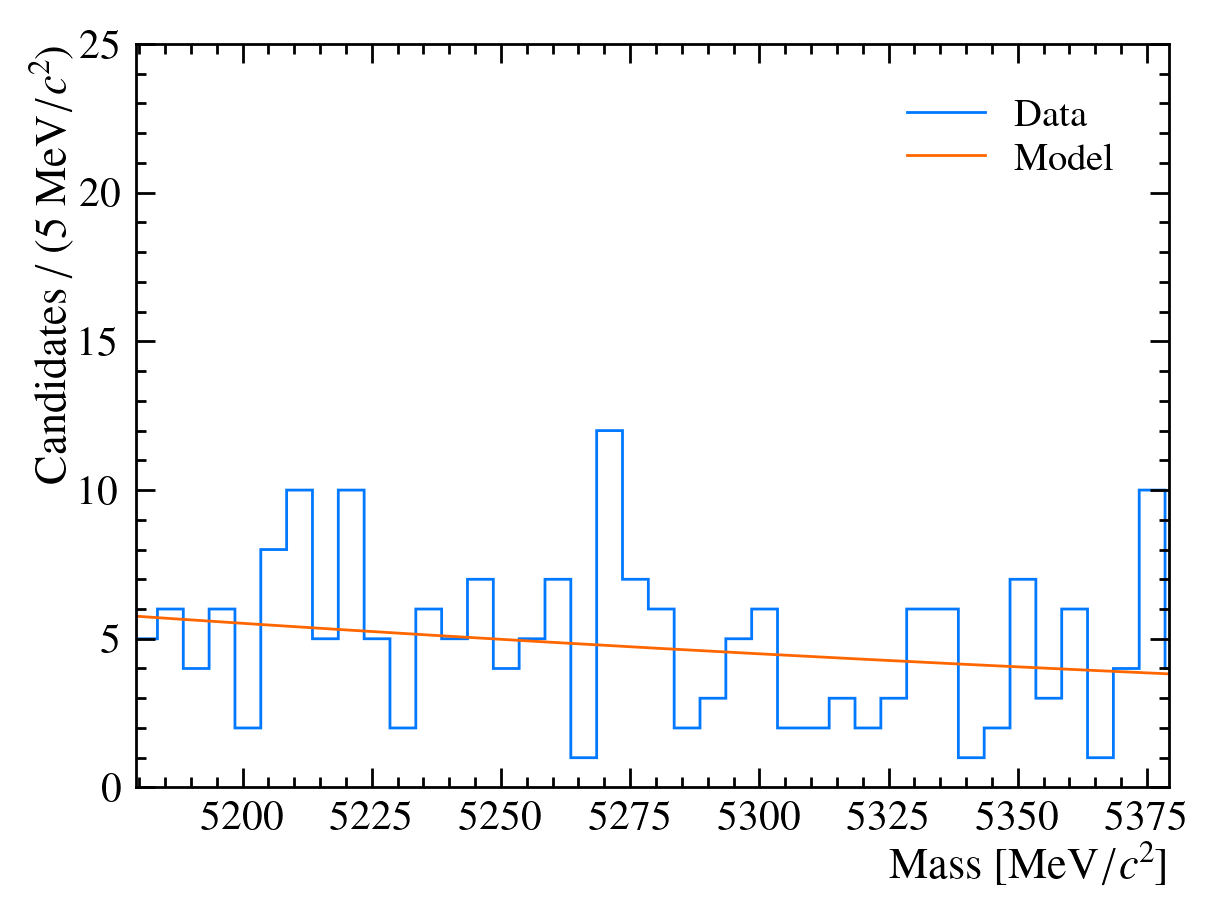

In [2]:
limits=(3650, 7000)
# limits = (4000, 7000)
data_in_limit = df[(df["Bplus_M"] >= limits[0]) & (df["Bplus_M"] <= limits[1])]["Bplus_M"]


obs = zfit.Space("Bplus_M", limits=limits)
lam = zfit.Parameter("lambda", -0.001)

data = zfit.Data.from_pandas(data_in_limit, obs=obs)
model = zfit.pdf.Exponential(lam=lam, obs=obs)

nll = zfit.loss.UnbinnedNLL(model=model, data=data)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss=nll)

print(result)

x = np.linspace(*obs.limit1d, num=1000)

fig, ax = histogram_fig(
    [p := HistogramPlot(df["Bplus_M"], "Data")],
    False,
    xlim=[3000, 8000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
probs_scaled = model.pdf(x) * len(data_in_limit) * p.bin_width

ax.plot(x, probs_scaled, label="Model", linewidth=2)
ax.legend()


fig, ax = histogram_fig(
    [p2 := HistogramPlot(df["Bplus_M"], "Data", bins=5)],
    False,
    xlim=[constant.BPLUS_MASS-100, constant.BPLUS_MASS + 100],
    ylim=[0,25],
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
)
probs_scaled = model.pdf(x) * len(data_in_limit) * p2.bin_width
ax.plot(x, probs_scaled, label="Model", linewidth=2)
ax.legend()


In [3]:
best_pidk_df, _ = filter_duplicates_by_performance(df, "Kplus_PIDK", "max")

FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[lambda, lambda]] data=[<zfit.Data: Data obs=('Bplus_M',) shape=(7651, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 8.1e-06 │         54916.28 |  8647.919 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
lambda         -0.00205866       False
Histogram not saved to file
Histogram not saved to file


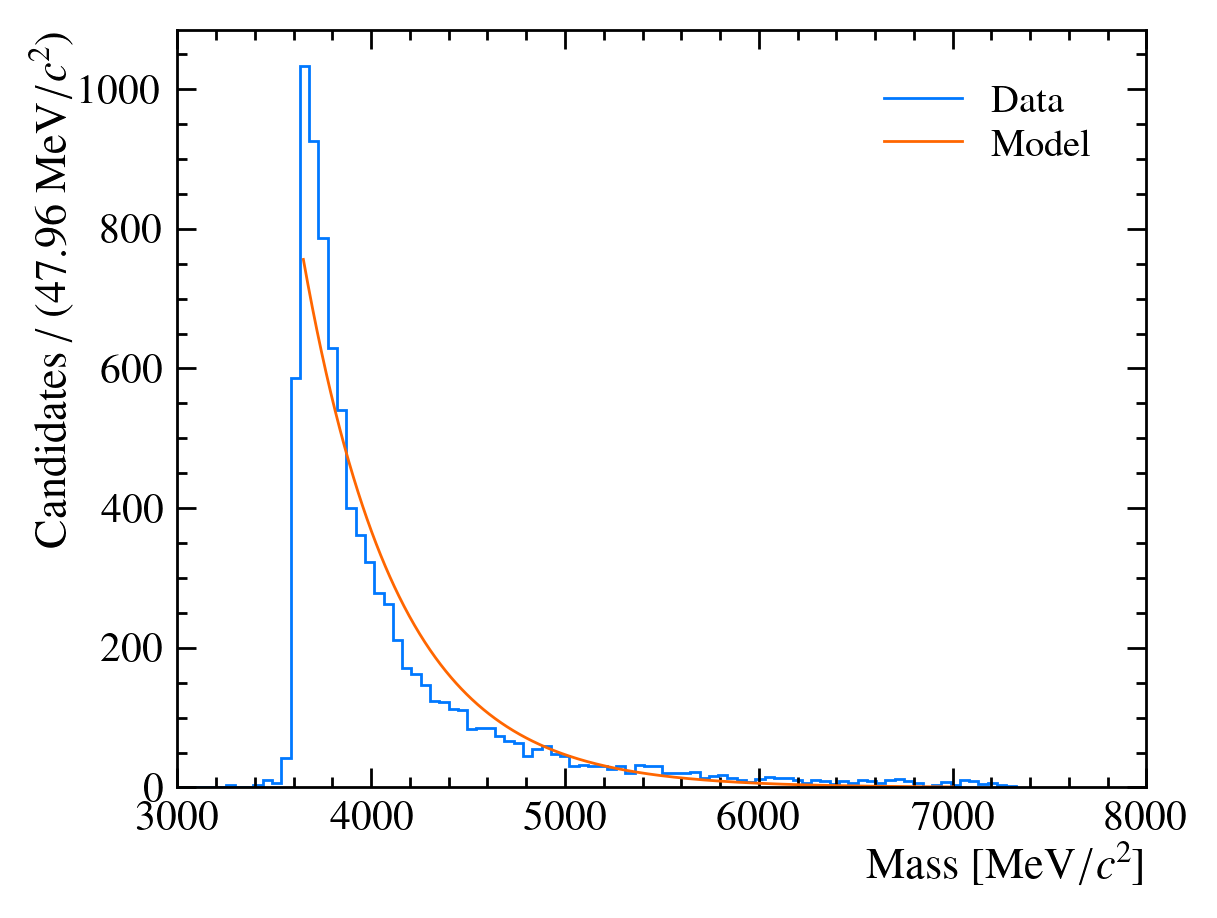

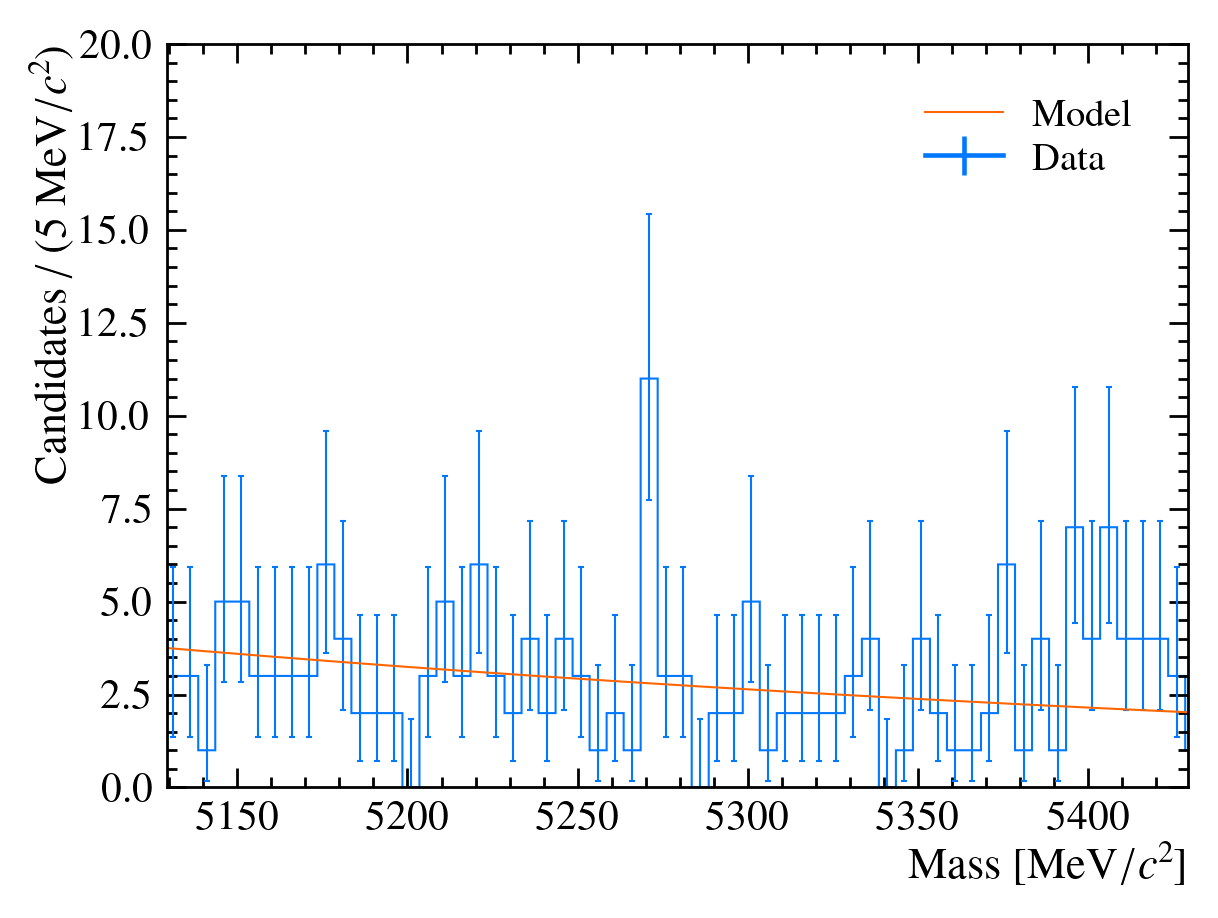

In [11]:
limits=(3650, 7000)
# limits = (4000, 7000)


data_in_limit = best_pidk_df[
    (best_pidk_df["Bplus_M"] >= limits[0])
    & (best_pidk_df["Bplus_M"] <= limits[1])
]["Bplus_M"]


obs = zfit.Space("Bplus_M", limits=limits)
lam = zfit.Parameter("lambda", -0.001)

data = zfit.Data.from_pandas(data_in_limit, obs=obs)
model = zfit.pdf.Exponential(lam=lam, obs=obs)

nll = zfit.loss.UnbinnedNLL(model=model, data=data)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss=nll)

print(result)

x = np.linspace(*obs.limit1d, num=1000)

fig, ax = histogram_fig(
    [p := HistogramPlot(best_pidk_df["Bplus_M"], "Data")],
    False,
    xlim=[3000, 8000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
probs_scaled = model.pdf(x) * len(data_in_limit) * p.bin_width

ax.plot(x, probs_scaled, label="Model", linewidth=2)
ax.legend()


fig, ax = histogram_fig(
    [p2 := HistogramPlot(best_pidk_df["Bplus_M"], "Data", bins=5, error = True, linewidth=1.5)],
    False,
    xlim=[constant.BPLUS_MASS - 150, constant.BPLUS_MASS + 150],
    ylim=[0, 20],
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
)
probs_scaled = model.pdf(x) * len(data_in_limit) * p2.bin_width
ax.plot(x, probs_scaled, label="Model", linewidth=1.5)
ax.legend()